In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, f1_score, recall_score, precision_score


X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"Доля оттока в train: {y_train.mean():.4f}")
print(f"Доля оттока в test: {y_test.mean():.4f}")

Train: (8000, 11)
Test: (2000, 11)
Доля оттока в train: 0.2037
Доля оттока в test: 0.2035


In [3]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [4]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1593
           1       0.63      0.61      0.62       407

    accuracy                           0.85      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.85      0.85      0.85      2000



In [5]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1593
           1       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



In [ ]:
models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

print(f"{'Модель':<25} {'F1':<10} {'Recall':<10} {'Precision':<10}")
print("=" * 60)

for name, y_pred in models.items():
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    print(f"{name:<25} {f1:<10.4f} {recall:<10.4f} {precision:<10.4f}")

Сравнение моделей:
Модель                    F1         Recall     Precision 
Logistic Regression       0.4987     0.7002     0.3872    
Random Forest             0.6202     0.6118     0.6288    
XGBoost                   0.6085     0.7371     0.5181    


XGBoost показал наилучший Recall 0.7371, что означает, что модель находит 74% клиентов, которые собираются уйти. Random Forest показал лучший F1 0.6202 и Precision 0.6288. Логистическая регрессия остаётся самой интерпретируемой, но уступает по F1.Для банка важнее Recall, так как лучше предложить удержание клиенту, который не собирался уходить, чем пропустить того, кто уйдёт. Поэтому для внедрения рекомендуется XGBoost.

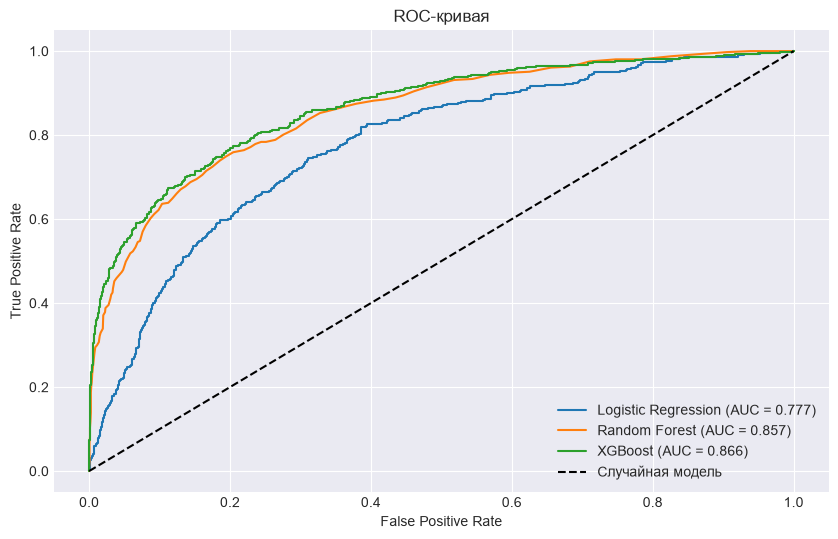

In [7]:
plt.figure(figsize=(10, 6))

for name, model in [('Logistic Regression', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True)
plt.savefig('../images/roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

ROC-кривая показывает AUC для каждой модели. XGBoost показал наилучший AUC 0.866, Random Forest 0.857, логистическая регрессия 0.777. Чем выше AUC, тем лучше модель различает классы.

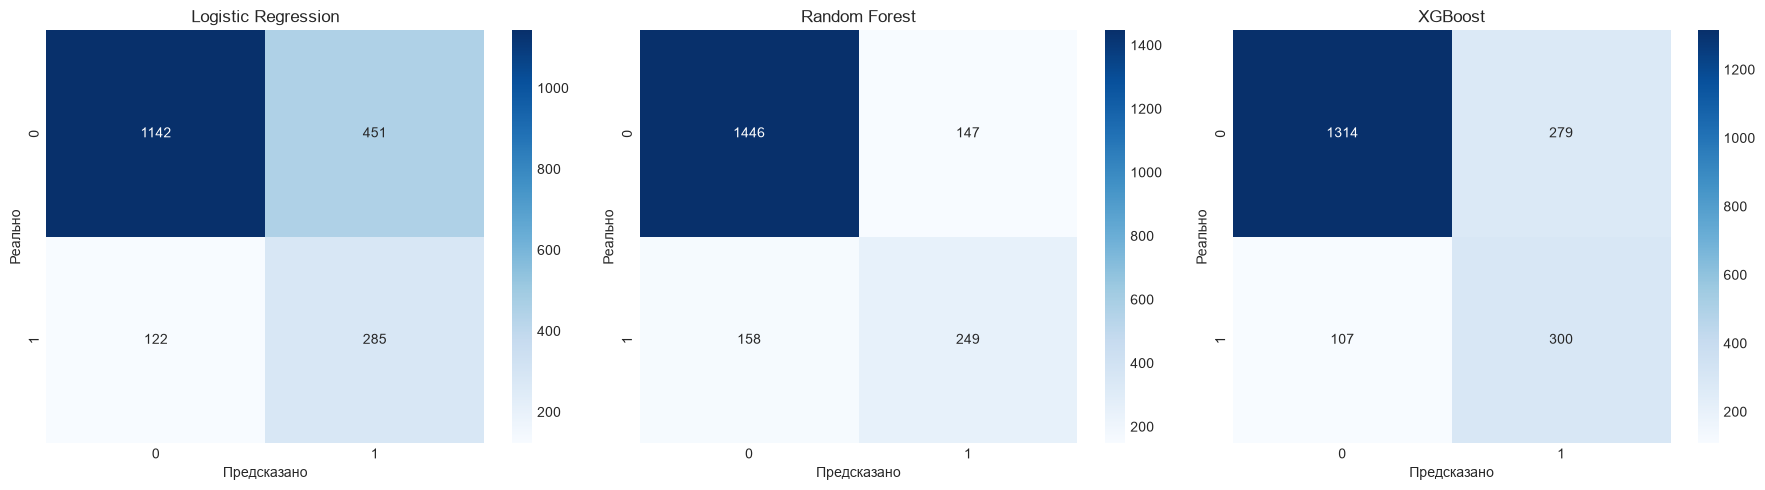

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Предсказано')
    axes[i].set_ylabel('Реально')

plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

Матрица ошибок показывает, что XGBoost поймал больше всех уходящих клиентов, 300 из 407, и пропустил меньше всех, 107. Random Forest показал минимум ложных срабатываний, 147, но пропустил 158 уходящих. Логистическая регрессия дала много ложных срабатываний, 451, но пропустила 122.

C:\Users\lerak\AppData\Local\Temp\ipykernel_13196\1040667791.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')


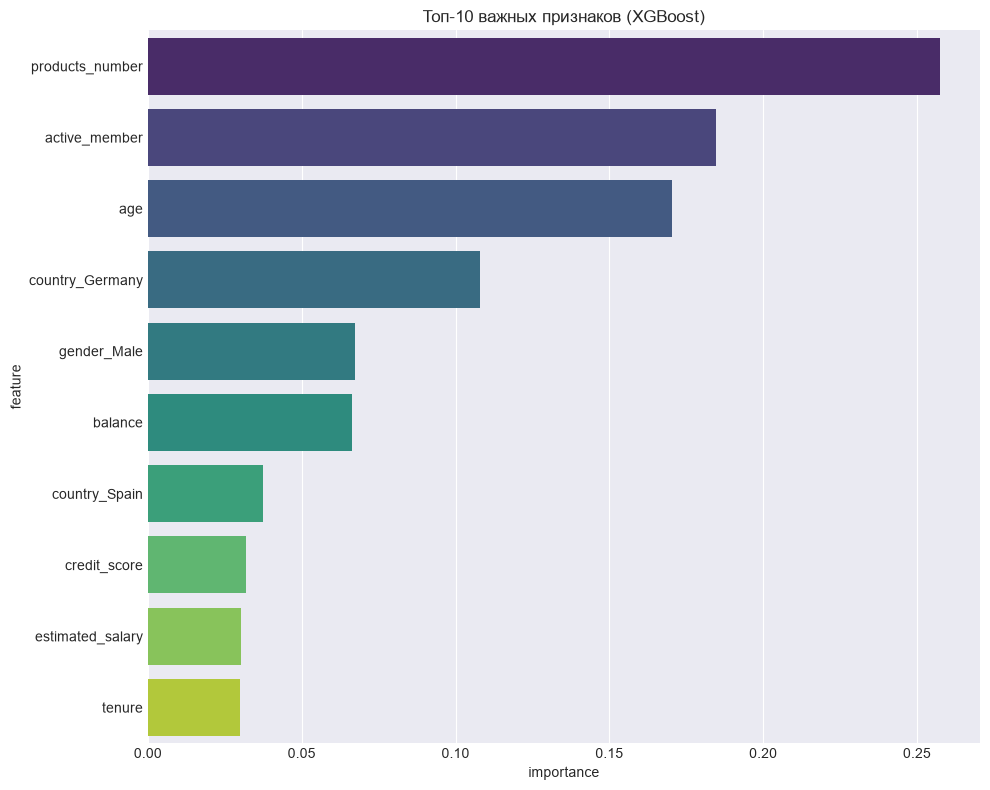

             feature  importance
4    products_number    0.257605
6      active_member    0.184603
1                age    0.170321
8    country_Germany    0.107937
10       gender_Male    0.067372
3            balance    0.066364
9      country_Spain    0.037581
0       credit_score    0.031815
7   estimated_salary    0.030223
2             tenure    0.029899


In [9]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Топ-10 важных признаков (XGBoost)')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print(feature_importance.head(10))

Наиболее важные признаки для предсказания оттока это возраст, количество продуктов и баланс. Это согласуется с результатами EDA и кластеризации.